# Phase 1 — Dataset Audit

Read-only audit of `data/chest_xray/`.

Goals:
- verify split/class counts and imbalance
- inspect image size, aspect ratio, and mode
- find corrupted files
- hash all images and report exact duplicates / cross-split leakage

This notebook does **not** create a new train/validation split.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.audit import (
    class_distribution,
    corrupted_images,
    count_table,
    cross_split_leakage,
    discover_images,
    duplicate_groups,
    hash_images,
    inspect_images,
    leakage_summary,
    mode_distribution,
    numeric_summary,
    within_split_duplicates,
)

DATA_DIR = PROJECT_ROOT / "data" / "chest_xray"
pd.set_option("display.max_colwidth", 120)
print("Project root:", PROJECT_ROOT)
print("Dataset dir:", DATA_DIR)
assert DATA_DIR.is_dir(), f"Missing dataset directory: {DATA_DIR}"

Project root: /home/fiores/Documents/hien-selflearning/pneumonia-detection
Dataset dir: /home/fiores/Documents/hien-selflearning/pneumonia-detection/data/chest_xray


## 1. Dataset inventory and counts

In [2]:
inventory = discover_images(DATA_DIR)
print(f"Total image files discovered: {len(inventory)}")
display(count_table(inventory))
display(inventory.head())

Total image files discovered: 5856


label,NORMAL,PNEUMONIA,TOTAL
train,1341,3875,5216
val,8,8,16
test,234,390,624
ALL,1583,4273,5856


,path,rel_path,split,label,filename,suffix,size_bytes
0,/home/fiores/Documents/hien-selflearning/pneumonia-detection/data/chest_xray/train/NORMAL/IM-0115-0001.jpeg,train/NORMAL/IM-0115-0001.jpeg,train,NORMAL,IM-0115-0001.jpeg,.jpeg,870784
1,/home/fiores/Documents/hien-selflearning/pneumonia-detection/data/chest_xray/train/NORMAL/IM-0117-0001.jpeg,train/NORMAL/IM-0117-0001.jpeg,train,NORMAL,IM-0117-0001.jpeg,.jpeg,406305
2,/home/fiores/Documents/hien-selflearning/pneumonia-detection/data/chest_xray/train/NORMAL/IM-0119-0001.jpeg,train/NORMAL/IM-0119-0001.jpeg,train,NORMAL,IM-0119-0001.jpeg,.jpeg,582639
3,/home/fiores/Documents/hien-selflearning/pneumonia-detection/data/chest_xray/train/NORMAL/IM-0122-0001.jpeg,train/NORMAL/IM-0122-0001.jpeg,train,NORMAL,IM-0122-0001.jpeg,.jpeg,471556
4,/home/fiores/Documents/hien-selflearning/pneumonia-detection/data/chest_xray/train/NORMAL/IM-0125-0001.jpeg,train/NORMAL/IM-0125-0001.jpeg,train,NORMAL,IM-0125-0001.jpeg,.jpeg,451292


## 2. Class distribution

,split,NORMAL,PNEUMONIA,total,pneumonia_ratio,normal_ratio
0,train,1341,3875,5216,0.742906,0.257094
1,val,8,8,16,0.500000,0.500000
2,test,234,390,624,0.625000,0.375000


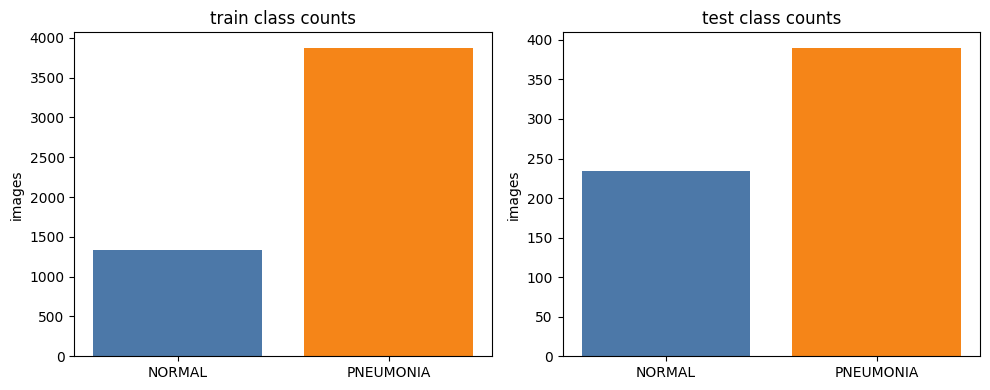

Original val is tiny (16 images); train pneumonia ratio: 0.743


In [3]:
dist = class_distribution(inventory)
display(dist)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, split in zip(axes, ["train", "test"]):
    row = dist.loc[dist["split"] == split].iloc[0]
    ax.bar(["NORMAL", "PNEUMONIA"], [row["NORMAL"], row["PNEUMONIA"]], color=["#4C78A8", "#F58518"])
    ax.set_title(f"{split} class counts")
    ax.set_ylabel("images")

plt.tight_layout()
plt.show()

print("Original val is tiny (16 images); train pneumonia ratio:",
      f"{dist.loc[dist['split'] == 'train', 'pneumonia_ratio'].iloc[0]:.3f}")

## 3–5. Image metadata (size, aspect ratio, mode) and corruption check

In [4]:
meta = inspect_images(inventory)
readable = meta[meta["readable"]]

print("Width stats")
display(pd.Series(numeric_summary(readable["width"]), name="width"))
print("Height stats")
display(pd.Series(numeric_summary(readable["height"]), name="height"))
print("Aspect-ratio stats (width / height)")
display(pd.Series(numeric_summary(readable["aspect_ratio"]), name="aspect_ratio"))

print("Mode distribution")
display(mode_distribution(meta))

bad = corrupted_images(meta)
print(f"Corrupted / unreadable images: {len(bad)}")
display(bad if len(bad) else pd.DataFrame(columns=["rel_path", "split", "label", "error"]))

Width stats


count     5856.000000
min        384.000000
max       2916.000000
mean      1327.880806
median    1281.000000
std        363.469884
Name: width, dtype: float64

Height stats


count     5856.000000
min        127.000000
max       2713.000000
mean       970.689037
median     888.000000
std        383.359381
Name: height, dtype: float64

Aspect-ratio stats (width / height)


count     5856.000000
min          0.835391
max          3.378788
mean         1.442986
median       1.415885
std          0.254334
Name: aspect_ratio, dtype: float64

Mode distribution


,mode,count,split
0,L,5573,ALL
1,RGB,283,ALL
2,L,624,test
3,L,4933,train
4,RGB,283,train
5,L,16,val


Corrupted / unreadable images: 0


,rel_path,split,label,error


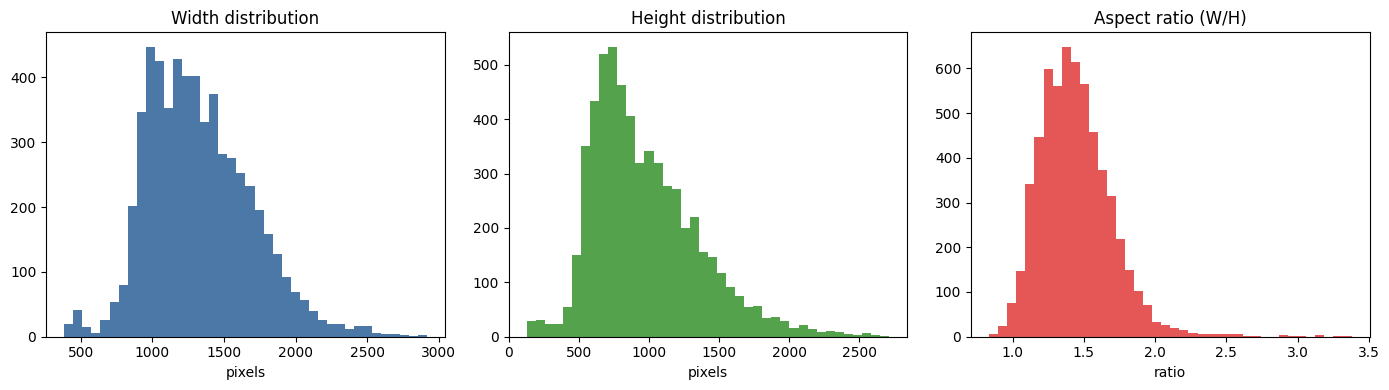

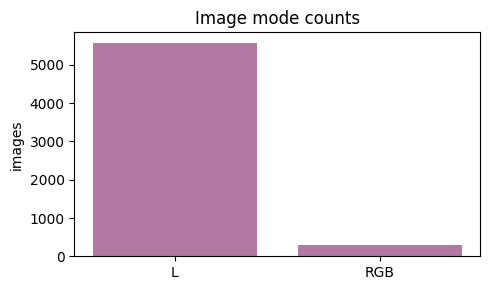

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(readable["width"], bins=40, color="#4C78A8")
axes[0].set_title("Width distribution")
axes[0].set_xlabel("pixels")

axes[1].hist(readable["height"], bins=40, color="#54A24B")
axes[1].set_title("Height distribution")
axes[1].set_xlabel("pixels")

axes[2].hist(readable["aspect_ratio"], bins=40, color="#E45756")
axes[2].set_title("Aspect ratio (W/H)")
axes[2].set_xlabel("ratio")

plt.tight_layout()
plt.show()

mode_counts = readable["mode"].value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(mode_counts.index.astype(str), mode_counts.values, color="#B279A2")
ax.set_title("Image mode counts")
ax.set_ylabel("images")
plt.tight_layout()
plt.show()

## 6–9. SHA-256 hashing, exact duplicates, and cross-split leakage

Hashing all images is deterministic and read-only. Exact duplicates share the same SHA-256.

In [6]:
hashed = hash_images(meta)
assert hashed["sha256"].notna().all()
print(f"Hashed images: {len(hashed)}")
print(f"Unique SHA-256 values: {hashed['sha256'].nunique()}")

dups = duplicate_groups(hashed)
print(f"Files involved in exact-duplicate groups: {len(dups)}")
print(f"Exact-duplicate hash groups: {dups['sha256'].nunique() if len(dups) else 0}")

within = within_split_duplicates(dups)
leakage = cross_split_leakage(dups)
summary = leakage_summary(leakage)

print("\nWithin-split duplicate groups:", len(within))
display(within.head(20) if len(within) else within)

print("\nCross-split leakage groups:", len(leakage))
display(leakage.head(50) if len(leakage) else leakage)
print("Leakage summary:", summary)

Hashed images: 5856
Unique SHA-256 values: 5824
Files involved in exact-duplicate groups: 62
Exact-duplicate hash groups: 30

Within-split duplicate groups: 30


,sha256,split,n_files,labels,files
0,0033d6b3f444134e4d3a320b4c9e34cdbc4ffe1fdb90023673ed1df46c643314,train,2,PNEUMONIA,train/PNEUMONIA/person1159_virus_1944.jpeg | train/PNEUMONIA/person1159_virus_1945.jpeg
1,1679da3844455b96ea5e792b12d24a832c4dba570628c27cb594fbfd7e2c9914,train,2,PNEUMONIA,train/PNEUMONIA/person124_virus_246.jpeg | train/PNEUMONIA/person124_virus_247.jpeg
2,1e273d0058cfb3cf5fb401b74797903a3e66c75fd2dbd8d14f4ef0890013d7c4,train,2,PNEUMONIA,train/PNEUMONIA/person1261_virus_2147.jpeg | train/PNEUMONIA/person1261_virus_2148.jpeg
3,3853a4552e0bc9aea1f45b2e7ee27be5954cdf9a0365d7972663b62b5495d9ae,train,2,NORMAL,train/NORMAL/NORMAL2-IM-0587-0001-0001.jpeg | train/NORMAL/NORMAL2-IM-0587-0001-0002.jpeg
4,409f0f6c0f8a5b8ed4e0645633b07812aff5991aaee75bbe48044711a55c7c2c,test,2,NORMAL,test/NORMAL/NORMAL2-IM-0173-0001-0001.jpeg | test/NORMAL/NORMAL2-IM-0173-0001-0002.jpeg
5,4d9f500ccfdde23bd7deb003994aeaf41537834458287bea61e9e80e78e8b091,train,2,PNEUMONIA,train/PNEUMONIA/person1481_bacteria_3866.jpeg | train/PNEUMONIA/person1481_bacteria_3867.jpeg
6,4e4df8461fc3412959b5c34abb54977332738400aeab75689b2c33ef00e27f99,train,2,PNEUMONIA,train/PNEUMONIA/person1496_bacteria_3909.jpeg | train/PNEUMONIA/person1496_bacteria_3910.jpeg
7,514afd0fa610117fbfef0e6e5b81a4d73a24815827594119af684fb8d0b2f8e2,test,2,PNEUMONIA,test/PNEUMONIA/person1661_virus_2872.jpeg | test/PNEUMONIA/person1661_virus_2873.jpeg
8,5824d55942d95216b7808fafa10db02aeaf63485a1a4f480faa951794a2d28b3,test,2,PNEUMONIA,test/PNEUMONIA/person128_bacteria_606.jpeg | test/PNEUMONIA/person128_bacteria_607.jpeg
9,704f62a1b29b3ae0ef1995610cc7cd63d9f0393bb5b653ded033cbcd1c92d409,train,2,PNEUMONIA,train/PNEUMONIA/person1628_bacteria_4297.jpeg | train/PNEUMONIA/person1628_bacteria_4298.jpeg



Cross-split leakage groups: 0


""


Leakage summary: {'n_leaked_hashes': 0, 'n_leaked_files': 0, 'split_pair_counts': {}}


In [7]:
# Show a compact view of leakage pairs if any exist
if len(leakage):
    pair_counts = pd.Series(summary["split_pair_counts"]).rename("n_hash_groups")
    display(pair_counts.to_frame())

    fig, ax = plt.subplots(figsize=(6, 3))
    pair_counts.plot(kind="bar", ax=ax, color="#FF9D98")
    ax.set_title("Exact-duplicate hash groups by split combination")
    ax.set_ylabel("groups")
    ax.set_xlabel("splits")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No cross-split exact content leakage detected.")

No cross-split exact content leakage detected.


## 10. Audit snapshot

In [8]:
snapshot = {
    "n_images": int(len(hashed)),
    "n_unique_sha256": int(hashed["sha256"].nunique()),
    "n_corrupted": int((~hashed["readable"]).sum()),
    "modes": hashed["mode"].fillna("UNREADABLE").value_counts().to_dict(),
    "width": numeric_summary(readable["width"]),
    "height": numeric_summary(readable["height"]),
    "aspect_ratio": numeric_summary(readable["aspect_ratio"]),
    "n_within_split_dup_groups": int(len(within)),
    "n_cross_split_leak_groups": int(len(leakage)),
    "leakage_summary": summary,
    "counts": count_table(inventory).to_dict(),
}
display(pd.Series({
    "n_images": snapshot["n_images"],
    "n_unique_sha256": snapshot["n_unique_sha256"],
    "n_corrupted": snapshot["n_corrupted"],
    "n_within_split_dup_groups": snapshot["n_within_split_dup_groups"],
    "n_cross_split_leak_groups": snapshot["n_cross_split_leak_groups"],
    "width_min": snapshot["width"]["min"],
    "width_max": snapshot["width"]["max"],
    "height_min": snapshot["height"]["min"],
    "height_max": snapshot["height"]["max"],
    "aspect_mean": snapshot["aspect_ratio"]["mean"],
}))

n_images                     5856.000000
n_unique_sha256              5824.000000
n_corrupted                     0.000000
n_within_split_dup_groups      30.000000
n_cross_split_leak_groups       0.000000
width_min                     384.000000
width_max                    2916.000000
height_min                    127.000000
height_max                   2713.000000
aspect_mean                     1.442986
dtype: float64

## 11. Conclusions for the next phase

In [9]:
train_row = dist.loc[dist["split"] == "train"].iloc[0]
val_row = dist.loc[dist["split"] == "val"].iloc[0]
test_row = dist.loc[dist["split"] == "test"].iloc[0]

print("Conclusions")
print("----------")
print(
    f"1. Counts: train={int(train_row['total'])}, "
    f"val={int(val_row['total'])}, test={int(test_row['total'])}, "
    f"grand_total={len(hashed)}."
)
print(
    "   Original val has only 16 images — too small for model selection. "
    "Phase 2 must build a stratified validation split from train and keep test locked."
)
print(
    f"2. Imbalance: train pneumonia ratio={train_row['pneumonia_ratio']:.3f} "
    f"(NORMAL={int(train_row['NORMAL'])}, PNEUMONIA={int(train_row['PNEUMONIA'])}). "
    "Later phases should treat accuracy carefully and plan class-weighted loss / recall focus."
)
print(
    f"3. Image stats: width[{snapshot['width']['min']:.0f}, {snapshot['width']['max']:.0f}], "
    f"height[{snapshot['height']['min']:.0f}, {snapshot['height']['max']:.0f}], "
    f"mean aspect={snapshot['aspect_ratio']['mean']:.3f}. "
    f"Modes={snapshot['modes']}. Resize is required; grayscale images need 3-channel expansion for ImageNet models."
)
print(f"4. Integrity: corrupted/unreadable files={snapshot['n_corrupted']}. Dataset was not modified.")
print(
    f"5. Duplicates: unique hashes={snapshot['n_unique_sha256']}/{snapshot['n_images']}; "
    f"within-split duplicate groups={snapshot['n_within_split_dup_groups']}; "
    f"cross-split leakage groups={snapshot['n_cross_split_leak_groups']}."
)
if snapshot["n_cross_split_leak_groups"]:
    print(
        "   Exact content appears across splits — Phase 2 / later evaluation must "
        "document this leakage risk; do not treat splits as fully independent."
    )
else:
    print("   No exact SHA-256 leakage across splits was found.")
print(
    "6. Next phase only: reproducible stratified train/validation split from original train. "
    "Do not tune on test."
)

Conclusions
----------
1. Counts: train=5216, val=16, test=624, grand_total=5856.
   Original val has only 16 images — too small for model selection. Phase 2 must build a stratified validation split from train and keep test locked.
2. Imbalance: train pneumonia ratio=0.743 (NORMAL=1341, PNEUMONIA=3875). Later phases should treat accuracy carefully and plan class-weighted loss / recall focus.
3. Image stats: width[384, 2916], height[127, 2713], mean aspect=1.443. Modes={'L': 5573, 'RGB': 283}. Resize is required; grayscale images need 3-channel expansion for ImageNet models.
4. Integrity: corrupted/unreadable files=0. Dataset was not modified.
5. Duplicates: unique hashes=5824/5856; within-split duplicate groups=30; cross-split leakage groups=0.
   No exact SHA-256 leakage across splits was found.
6. Next phase only: reproducible stratified train/validation split from original train. Do not tune on test.
